In [22]:
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import math

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import StratifiedKFold
from sklearn.inspection import permutation_importance
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict

## ML Baseline

### Parsing into Pandas

In [23]:
def build_features_polars(parquet_path):

    cat_features = ["B_30", "B_38", "D_114", "D_116", "D_117", "D_120",
                    "D_126", "D_63", "D_64", "D_66", "D_68"]

    schema = pl.scan_parquet(parquet_path).collect_schema()
    all_cols = schema.names()

    numeric_dtypes = (pl.Float32, pl.Float64, pl.Int8, pl.Int16, pl.Int32,
                      pl.Int64, pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64)
    num_features = [c for c in all_cols
                    if c not in ['customer_ID', 'S_2'] + cat_features
                    and schema[c] in numeric_dtypes]

    print(f"  {len(num_features)} numeric features, {len(cat_features)} categorical")

    print("  building aggregation expressions...")
    num_agg_exprs = []
    for c in num_features:
        num_agg_exprs.extend([
            pl.col(c).mean().alias(f"{c}_mean"),
            pl.col(c).last().alias(f"{c}_last"),
        ])

    cat_agg_exprs = []
    for c in cat_features:
        cat_agg_exprs.extend([
            pl.col(c).last().alias(f"{c}_last"),
            pl.col(c).n_unique().alias(f"{c}_nunique"),
        ])

    count_expr = [pl.len().alias("n_statements")]

    print("  running numeric aggregation → sink (streaming)...")
    numeric_path = "test_features_numeric.parquet"
    (pl.scan_parquet(parquet_path)
       .group_by("customer_ID")
       .agg(num_agg_exprs + count_expr)
       .sink_parquet(numeric_path, engine="streaming")
    )

    print("  running categorical aggregation → sink...")
    cat_path = "test_features_cat.parquet"
    (pl.scan_parquet(parquet_path)
       .select(["customer_ID"] + cat_features)
       .group_by("customer_ID")
       .agg(cat_agg_exprs)
       .sink_parquet(cat_path, engine="streaming")
    )

    print("  joining results...")
    result = pl.read_parquet(numeric_path).join(
        pl.read_parquet(cat_path), on="customer_ID"
    )
    result = result.with_columns(pl.col(pl.Float64).cast(pl.Float32))

    print(f"  final shape: {result.shape}")
    return result.to_pandas()

In [42]:
pl.scan_csv("/kaggle/input/competitions/amex-default-prediction/train_data.csv").sink_parquet("/kaggle/working/train.parquet")
print("Train done")

Train done


In [25]:
train = build_features_polars("/kaggle/working/train.parquet")

  156 numeric features, 11 categorical
  building aggregation expressions...
  running numeric aggregation → sink (streaming)...
  running categorical aggregation → sink...
  joining results...
  final shape: (458913, 336)


In [26]:
train.head()

,customer_ID,P_2_mean,P_2_last,D_39_mean,D_39_last,B_1_mean,B_1_last,B_2_mean,B_2_last,R_1_mean,...,D_126_last,D_126_nunique,D_63_last,D_63_nunique,D_64_last,D_64_nunique,D_66_last,D_66_nunique,D_68_last,D_68_nunique
0,cb08531214943c51575df95adba0caeddb9656c158b3e6...,0.761604,0.755769,0.181913,0.036215,0.543573,0.681320,0.123572,0.019880,0.003628,...,1.0,2,CO,1,O,2,NaN,1,6.0,2
1,d5c671b2dd5760cfa12e7c11deb4e610fc0e83da019bcb...,0.829961,0.846654,0.153114,0.062765,0.032563,0.043747,1.003415,1.004582,0.005431,...,1.0,1,CO,1,O,2,NaN,1,6.0,1
2,044611d2f68538f617379216d66febf6723c383a4d002a...,0.445619,0.429889,0.081390,0.035554,0.061560,0.098079,0.235826,0.031762,0.405854,...,1.0,2,CO,1,O,2,NaN,1,4.0,3
3,a4549400c09770faff404be93bf7ae90eea1e462effb69...,0.812618,0.816589,0.074797,0.178595,0.022019,0.045132,1.005132,1.004945,0.005567,...,1.0,3,CR,1,R,1,NaN,1,6.0,1
4,c23bbc83e3a296d2d2cb55026bf85e15da08f2603cfe3e...,0.560833,0.559790,0.006158,0.005810,0.011550,0.005653,0.829575,0.816952,0.003773,...,1.0,2,CR,1,O,2,NaN,1,5.0,2


In [27]:
labels_path = "/kaggle/input/competitions/amex-default-prediction/train_labels.csv"
labels_df = pd.read_csv(labels_path)
labels_df.head()

,customer_ID,target
0,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,0
1,00000fd6641609c6ece5454664794f0340ad84dddce9a2...,0
2,00001b22f846c82c51f6e3958ccd81970162bae8b007e8...,0
3,000041bdba6ecadd89a52d11886e8eaaec9325906c9723...,0
4,00007889e4fcd2614b6cbe7f8f3d2e5c728eca32d9eb8a...,0


In [28]:
train_df = pd.merge(labels_df, train, on='customer_ID', how='inner')
train_df.head()

,customer_ID,target,P_2_mean,P_2_last,D_39_mean,D_39_last,B_1_mean,B_1_last,B_2_mean,B_2_last,...,D_126_last,D_126_nunique,D_63_last,D_63_nunique,D_64_last,D_64_nunique,D_66_last,D_66_nunique,D_68_last,D_68_nunique
0,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,0,0.933824,0.934745,0.010704,0.009119,0.012007,0.009382,1.005086,1.007647,...,1.0,1,CR,1,O,1,NaN,1,6.0,1
1,00000fd6641609c6ece5454664794f0340ad84dddce9a2...,0,0.899820,0.880519,0.215205,0.178126,0.025654,0.034684,0.991083,1.004028,...,1.0,1,CO,1,O,1,NaN,1,6.0,1
2,00001b22f846c82c51f6e3958ccd81970162bae8b007e8...,0,0.878454,0.880875,0.004181,0.009704,0.004386,0.004284,0.815677,0.812649,...,1.0,1,CO,1,R,1,NaN,1,6.0,1
3,000041bdba6ecadd89a52d11886e8eaaec9325906c9723...,0,0.598969,0.621776,0.048862,0.001083,0.059876,0.012564,0.955265,1.006183,...,1.0,1,CO,1,O,1,NaN,1,3.0,3
4,00007889e4fcd2614b6cbe7f8f3d2e5c728eca32d9eb8a...,0,0.891679,0.871900,0.004644,0.005573,0.005941,0.007679,0.814543,0.815746,...,1.0,1,CO,1,O,1,1.0,1,6.0,1


### Hist Gradient Boosting Algorithm

In [29]:
X = train_df.drop(columns=["customer_ID", "target"])
y = train_df["target"]
import gc
del train_df
gc.collect()

27

In [30]:
text_cols = X.select_dtypes(include=["object", "string"]).columns.tolist()

if text_cols:
  X = X.drop(columns=text_cols)

X = X.select_dtypes(include=[np.number])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds_ml = np.zeros(len(X))
cv_scores_ml = []
train_scores_ml = []
models_list_ml = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    
    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

    model = HistGradientBoostingClassifier(max_iter=150, 
                                           learning_rate=0.1, 
                                           l2_regularization=0.5,
                                           random_state=336, 
                                           verbose=0
                                          )

    model.fit(X_train, y_train)
    models_list_ml.append(model)

    train_preds_ml = model.predict_proba(X_train)[:, 1]
    train_auc_ml = roc_auc_score(y_train, train_preds_ml)
    train_scores_ml.append(train_auc_ml)
    
    val_preds_ml = model.predict_proba(X_val)[:, 1]
    oof_preds_ml[val_idx] = val_preds_ml
    
    fold_auc_ml = roc_auc_score(y_val, val_preds_ml)
    cv_scores_ml.append(fold_auc_ml)
    
    print(f"Fold {fold + 1} | Train AUC: {train_auc_ml:.4f} | Val (OOF) AUC:"f" {fold_auc_ml:.4f}")

    if fold == 4:
        last_model = model
        last_X_val = X_val
        last_y_val = y_val

    del X_train, y_train, X_val, y_val
    gc.collect()

overall_auc = roc_auc_score(y, oof_preds_ml)
print(f"\nTotal OOF ROC-AUC: {overall_auc:.4f}")

Fold 1 | Train AUC: 0.9659 | Val (OOF) AUC: 0.9608
Fold 2 | Train AUC: 0.9662 | Val (OOF) AUC: 0.9595
Fold 3 | Train AUC: 0.9662 | Val (OOF) AUC: 0.9600
Fold 4 | Train AUC: 0.9662 | Val (OOF) AUC: 0.9594
Fold 5 | Train AUC: 0.9660 | Val (OOF) AUC: 0.9602

Total OOF ROC-AUC: 0.9600


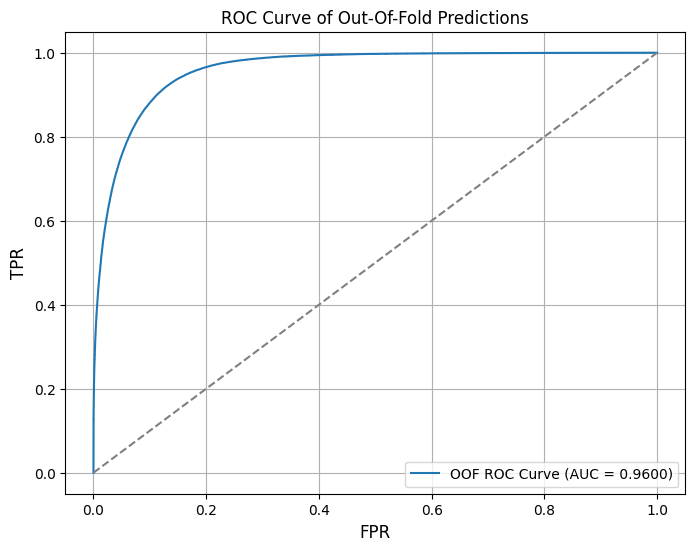

In [31]:
fpr, tpr, thresholds = roc_curve(y, oof_preds_ml)

plt.figure(figsize=(8, 6))
plt.plot(fpr,tpr, label=f"OOF ROC Curve (AUC = {overall_auc:.4f})")
plt.plot([0, 1], [0, 1], color="grey", linestyle="--")
plt.xlabel("FPR", fontsize=12)
plt.ylabel("TPR", fontsize=12)
plt.title("ROC Curve of Out-Of-Fold Predictions")
plt.legend()
plt.grid()
plt.show()

In [32]:
result = permutation_importance(
    last_model,
    last_X_val,
    last_y_val,
    scoring="roc_auc",
    n_repeats=3,
    random_state=42,
    n_jobs=-1
)

feature_importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance_mean": result.importances_mean,
    "importance_std": result.importances_std}
                                    ).sort_values(by="importance_mean", ascending=False)

print("\nTOP 10 features:")
print(feature_importance_df.head(10))


TOP 10 features:
      feature  importance_mean  importance_std
1    P_2_last         0.017834        0.000248
5    B_1_last         0.002436        0.000139
23   B_4_last         0.001841        0.000023
3   D_39_last         0.001685        0.000061
16  D_42_mean         0.001254        0.000058
15   B_3_last         0.000875        0.000036
31  D_46_last         0.000619        0.000013
27   B_5_last         0.000517        0.000024
10   S_3_mean         0.000490        0.000063
13  D_41_last         0.000371        0.000047


In [ ]:
import os
os.remove("/kaggle/working/train.parquet")

### Test Submision

In [34]:
pl.scan_csv("/kaggle/input/competitions/amex-default-prediction/test_data.csv").sink_parquet('test.parquet')

In [35]:
test_df = build_features_polars("/kaggle/working/test.parquet")

  164 numeric features, 11 categorical
  building aggregation expressions...
  running numeric aggregation → sink (streaming)...
  running categorical aggregation → sink...
  joining results...
  final shape: (924621, 352)


In [36]:
os.remove("/kaggle/working/test.parquet")

In [37]:
X_test = test_df.drop(columns=["customer_ID"], errors="ignore")
X_test = X_test[X.columns]
X_test = X_test.select_dtypes(include=[np.number])
final_preds_ml = np.zeros(len(X_test))

for model in models_list_ml:
  preds = model.predict_proba(X_test)[:, 1]
  final_preds_ml += preds / len(models_list_ml)

submission_ml = pd.DataFrame(
    {"customer_ID": test_df["customer_ID"], "prediction": final_preds_ml}
)

submission_ml.to_csv("submission.csv", index=False)

In [38]:
!kaggle competitions submit -c amex-default-prediction -f submission.csv -m "HistGradientBoosting baseline submission"

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/urllib3/connection.py", line 198, in _new_conn
    sock = connection.create_connection(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/urllib3/util/connection.py", line 60, in create_connection
    for res in socket.getaddrinfo(host, port, family, socket.SOCK_STREAM):
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/socket.py", line 978, in getaddrinfo
    for res in _socket.getaddrinfo(host, port, family, type, proto, flags):
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
socket.gaierror: [Errno -3] Temporary failure in name resolution

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py", line 787, in urlopen
    response = self._make_request(
             

## Deep Learning Model

### Preprocessing

In [39]:
class AmexPreprocessor:
    def __init__(self, cat_features_base):
        self.cat_features_base = cat_features_base
        self.num_imputer = SimpleImputer(strategy='median')
        self.scaler = StandardScaler()
        self.cat_imputer = SimpleImputer(strategy='constant', fill_value='missing')
        self.label_encoders = {}
        
        self.num_cols = []
        self.cat_cols = []
        self.cat_dims = []

    def fit_transform(self, df):
        df = df.copy()
        self.cat_cols = [f"{c}_last" for c in self.cat_features_base if f"{c}_last" in df.columns]
        exclude_cols = ['customer_ID', 'target'] + self.cat_cols
        self.num_cols = [c for c in df.columns if c not in exclude_cols]
        
        df[self.num_cols] = self.num_imputer.fit_transform(df[self.num_cols])
        df[self.num_cols] = self.scaler.fit_transform(df[self.num_cols])
        df[self.cat_cols] = self.cat_imputer.fit_transform(df[self.cat_cols])
        
        self.cat_dims = []
        for col in self.cat_cols:
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col].astype(str))
            self.label_encoders[col] = le
            self.cat_dims.append(len(le.classes_))
            
        return df, self.num_cols, self.cat_cols, self.cat_dims
        
    def transform(self, df):
        df = df.copy()
        df[self.num_cols] = self.num_imputer.transform(df[self.num_cols])
        df[self.num_cols] = self.scaler.transform(df[self.num_cols])
        df[self.cat_cols] = self.cat_imputer.transform(df[self.cat_cols])
        
        for col in self.cat_cols:
            le = self.label_encoders[col]
            known_classes = set(le.classes_)
            df[col] = df[col].astype(str).apply(lambda x: x if x in known_classes else le.classes_[0])
            df[col] = le.transform(df[col])
            
        return df

### Training and validation

In [40]:
class AmexDataset(Dataset):
    def __init__(self, df, num_cols, cat_cols, has_target=True):
        self.X_num = torch.tensor(df[num_cols].values, dtype=torch.float32)
        self.X_cat = torch.tensor(df[cat_cols].values, dtype=torch.long)
        self.has_target = has_target
        if has_target:
            self.y = torch.tensor(df['target'].values, dtype=torch.float32).unsqueeze(1)
            
    def __len__(self):
        return len(self.X_num)
        
    def __getitem__(self, idx):
        if self.has_target:
            return self.X_cat[idx], self.X_num[idx], self.y[idx]
        return self.X_cat[idx], self.X_num[idx]

class CustomLinearWithNorm(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.weight = nn.Parameter(torch.empty((out_features, in_features)))
        self.bias = nn.Parameter(torch.zeros(out_features))
        nn.init.kaiming_uniform_(self.weight, a=math.sqrt(5))
        
    def forward(self, x):
        norm_weight = F.normalize(self.weight, p=2, dim=1)
        return F.linear(x, norm_weight, self.bias)

class AmexDeepModel(nn.Module):
    def __init__(self, cat_dims, num_features):
        super().__init__()
        self.embeddings = nn.ModuleList([
            nn.Embedding(num_embeddings=dim, embedding_dim=min(50, (dim + 1) // 2))
            for dim in cat_dims
        ])
        total_emb_dim = sum(min(50, (dim + 1) // 2) for dim in cat_dims)
        
        self.num_branch = nn.Sequential(
            CustomLinearWithNorm(num_features, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3)
        )
        
        combined_dim = total_emb_dim + 128
        self.fc1 = nn.Linear(combined_dim, 256)
        self.bn1 = nn.BatchNorm1d(256)
        self.fc2 = nn.Linear(256, 64)
        self.bn2 = nn.BatchNorm1d(64)
        
        self.aux_output = nn.Linear(256, 1)
        self.main_output = nn.Linear(64, 1)

    def forward(self, x_cat, x_num):
        emb_outs = [emb(x_cat[:, i]) for i, emb in enumerate(self.embeddings)]
        x_cat_emb = torch.cat(emb_outs, dim=1) if emb_outs else torch.empty(x_cat.size(0), 0, device=x_cat.device)
        x_num_out = self.num_branch(x_num)
        x = torch.cat([x_cat_emb, x_num_out], dim=1)
        
        x = self.fc1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = F.dropout(x, p=0.4, training=self.training)
        
        aux_out = self.aux_output(x)
        
        x = self.fc2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = F.dropout(x, p=0.2, training=self.training)
        main_out = self.main_output(x)
        
        return main_out, aux_out

class CustomAdamW(optim.Optimizer):
    def __init__(self, params, lr=1e-3, betas=(0.9, 0.999), eps=1e-8, weight_decay=1e-2):
        defaults = dict(lr=lr, betas=betas, eps=eps, weight_decay=weight_decay)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None):
        loss = closure() if closure is not None else None
        for group in self.param_groups:
            for p in group['params']:
                if p.grad is None: continue
                grad = p.grad
                state = self.state[p]

                if len(state) == 0:
                    state['step'] = 0
                    state['exp_avg'] = torch.zeros_like(p)
                    state['exp_avg_sq'] = torch.zeros_like(p)

                exp_avg, exp_avg_sq = state['exp_avg'], state['exp_avg_sq']
                beta1, beta2 = group['betas']
                state['step'] += 1

                p.mul_(1 - group['lr'] * group['weight_decay'])
                exp_avg.mul_(beta1).add_(grad, alpha=1 - beta1)
                exp_avg_sq.mul_(beta2).addcmul_(grad, grad, value=1 - beta2)

                bias_correction1 = 1 - beta1 ** state['step']
                bias_correction2 = 1 - beta2 ** state['step']
                step_size = group['lr'] / bias_correction1
                denom = (exp_avg_sq.sqrt() / math.sqrt(bias_correction2)).add_(group['eps'])

                p.addcdiv_(exp_avg, denom, value=-step_size)
        return loss

def plot_gradient_flow(named_parameters):
    ave_grads = []
    layers = []
    for n, p in named_parameters:
        if (p.requires_grad) and ("bias" not in n) and (p.grad is not None):
            layers.append(n)
            ave_grads.append(p.grad.abs().mean().item())
    
    plt.figure(figsize=(10, 4))
    plt.bar(np.arange(len(ave_grads)), ave_grads, alpha=0.5, color="b")
    plt.xticks(range(0, len(ave_grads), 1), layers, rotation=45, ha="right")
    plt.title("Gradient Flow (Average Absolute Gradients)")
    plt.xlabel("Layers")
    plt.ylabel("Average Gradient")
    plt.tight_layout()
    plt.show()


def train_amex_cv(df_full, cat_features_base, epochs=10, batch_size=512, n_splits=5):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Starting Stratified {n_splits}-Fold CV on {device}...")
    
    targets = df_full['target'].values
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    oof_predictions = np.zeros(len(df_full))
    fold_auc_scores = []
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(df_full, targets)):
        print(f"\n{'='*20} Fold {fold + 1}/{n_splits} {'='*20}")
        
        df_train_fold = df_full.iloc[train_idx].reset_index(drop=True)
        df_val_fold = df_full.iloc[val_idx].reset_index(drop=True)
        
        preprocessor = AmexPreprocessor(cat_features_base)
        df_train_proc, num_cols, cat_cols, cat_dims = preprocessor.fit_transform(df_train_fold)
        df_val_proc = preprocessor.transform(df_val_fold)
        
        train_loader = DataLoader(AmexDataset(df_train_proc, num_cols, cat_cols), batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(AmexDataset(df_val_proc, num_cols, cat_cols), batch_size=batch_size, shuffle=False)
        
        model = AmexDeepModel(cat_dims, len(num_cols)).to(device)
        criterion = nn.BCEWithLogitsLoss()
        optimizer = CustomAdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
        scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=5e-3, 
                                                  steps_per_epoch=len(train_loader), epochs=epochs)
        aux_weight = 0.3
        
        for epoch in range(epochs):
            model.train()
            train_loss = 0
            for x_cat, x_num, y in train_loader:
                x_cat, x_num, y = x_cat.to(device), x_num.to(device), y.to(device)
                
                optimizer.zero_grad()
                main_pred, aux_pred = model(x_cat, x_num)
                loss = criterion(main_pred, y) + aux_weight * criterion(aux_pred, y)
                loss.backward()
                optimizer.step()
                scheduler.step()
                train_loss += loss.item()
                
            model.eval()
            val_preds, val_targets = [], []
            with torch.no_grad():
                for x_cat, x_num, y in val_loader:
                    x_cat, x_num = x_cat.to(device), x_num.to(device)
                    main_pred, _ = model(x_cat, x_num)
                    val_preds.extend(torch.sigmoid(main_pred).cpu().numpy())
                    val_targets.extend(y.numpy())
            
            val_auc = roc_auc_score(val_targets, val_preds)
            print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss/len(train_loader):.4f} | Val AUC: {val_auc:.4f}")
            
        oof_predictions[val_idx] = np.array(val_preds).squeeze()
        fold_auc_scores.append(val_auc)
        print(f"Best Fold {fold + 1} AUC: {val_auc:.4f}")
        
    global_auc = roc_auc_score(targets, oof_predictions)
    print(f"\n{'='*50}")
    print(f"Average AUC by folds: {np.mean(fold_auc_scores):.4f} ± {np.std(fold_auc_scores):.4f}")
    print(f"Global OOF AUC: {global_auc:.4f}")
    
    return oof_predictions, fold_auc_scores


In [ ]:
if __name__ == "__main__":
    df_train_agg = build_features_polars("/kaggle/working/train.parquet")
    train_labels = pd.read_csv("/kaggle/input/competitions/amex-default-prediction/train_labels.csv") 
    df_train_full = df_train_agg.merge(train_labels, on="customer_ID", how="left")

    cat_features_base = ["B_30", "B_38", "D_114", "D_116", "D_117", "D_120",
                         "D_126", "D_63", "D_64", "D_66", "D_68"]

    oof_preds, cv_scores = train_amex_cv(df_train_full, cat_features_base, epochs=10)

In [ ]:
def plot_cv_roc(targets, oof_predictions):
    fpr, tpr, _ = roc_curve(targets, oof_predictions)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='orange', label=f'OOF ROC AUC = {roc_auc:.4f}')
    plt.plot([0, 1], [0, 1], color='grey', lw=2, linestyle='--')
    plt.xlabel('FPR')
    plt.ylabel('TPR')
    plt.title('Receiver Operating Characteristic (Out-Of-Fold)')
    plt.legend()
    plt.grid()
    plt.show()

plot_cv_roc(df_train_full['target'].values, oof_preds)

### Submission

In [ ]:
test_parquet_path = "/kaggle/working/test.parquet"
epochs = 10
batch_size = 512
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Agregation...")
df_test_agg = build_features_polars(test_parquet_path)

print("Preprocessing...")
preprocessor = AmexPreprocessor(cat_features_base)
df_train_proc, num_cols, cat_cols, cat_dims = preprocessor.fit_transform(df_train_full)
df_test_proc = preprocessor.transform(df_test_agg)

print(f"Training the final model on 100% of data ({device})...")
train_loader = DataLoader(
    AmexDataset(df_train_proc, num_cols, cat_cols, has_target=True), 
    batch_size=batch_size, 
    shuffle=True
)

model = AmexDeepModel(cat_dims, len(num_cols)).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = CustomAdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer, 
    max_lr=5e-3, 
    steps_per_epoch=len(train_loader), 
    epochs=epochs
)

aux_weight = 0.3
model.train()

for epoch in range(epochs):
    train_loss = 0
    for x_cat, x_num, y in train_loader:
        x_cat, x_num, y = x_cat.to(device), x_num.to(device), y.to(device)
        optimizer.zero_grad()
        
        main_pred, aux_pred = model(x_cat, x_num)
        loss = criterion(main_pred, y) + aux_weight * criterion(aux_pred, y)
        
        loss.backward()
        optimizer.step()
        scheduler.step()
        
        train_loss += loss.item()
        
    print(f"Full Fit Epoch {epoch+1}/{epochs} | Loss: {train_loss/len(train_loader):.4f}")

print("Predicting for submission...")
# has_target=False, оскільки в тестових даних немає цільової змінної
test_loader = DataLoader(
    AmexDataset(df_test_proc, num_cols, cat_cols, has_target=False), 
    batch_size=batch_size, 
    shuffle=False
)

model.eval()
test_preds = []

with torch.no_grad():
    for x_cat, x_num in test_loader:
        x_cat, x_num = x_cat.to(device), x_num.to(device)
        main_pred, _ = model(x_cat, x_num)
        
        probs = torch.sigmoid(main_pred).cpu().numpy()
        test_preds.extend(probs)

submission = pd.DataFrame({
    'customer_ID': df_test_agg['customer_ID'],
    'prediction': np.array(test_preds).squeeze()
})

submission.to_csv("submission_dl.csv", index=False)
print("File submission_dl.csv is saved successfully")

## Ensembling

In [ ]:
train_df_ids = pd.merge(labels_df, train, on='customer_ID', how='inner')['customer_ID'].reset_index(drop=True)

print("ML OOF AUC:", roc_auc_score(y, oof_preds_ml)) 

oof_preds_dl = oof_preds.copy()
dl_customer_ids = df_train_full['customer_ID'].values
dl_target = df_train_full['target'].values

print("DL OOF AUC:", roc_auc_score(dl_target, oof_preds_dl))

In [ ]:
ml_oof_df = pd.DataFrame({'customer_ID': train_df_ids.values, 'ml_pred': oof_preds_ml})
dl_oof_df = pd.DataFrame({'customer_ID': dl_customer_ids, 'dl_pred': oof_preds_dl})

stack_df = ml_oof_df.merge(dl_oof_df, on='customer_ID').merge(labels_df, on='customer_ID')

In [ ]:
stack_df.shape

In [ ]:
stack_df.head()

In [ ]:
meta_X = stack_df[['ml_pred', 'dl_pred']].values
meta_y = stack_df['target'].values

meta_model = LogisticRegression()
meta_skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
meta_oof_preds = cross_val_predict(meta_model, stack_df[['ml_pred', 'dl_pred']].values, stack_df['target'].values, cv=meta_skf, method='predict_proba')[:, 1]

print(f"HGB OOF AUC: {roc_auc_score(stack_df['target'].values, stack_df['ml_pred']):.4f}")
print(f"DL OOF AUC: {roc_auc_score(stack_df['target'].values, stack_df['dl_pred']):.4f}")
print(f"Ensemble OOF AUC: {roc_auc_score(stack_df['target'].values, meta_oof_preds):.4f}")

In [ ]:
final_model = LogisticRegression()
final_model.fit(stack_df[['ml_pred', 'dl_pred']].values, stack_df['target'].values)

In [ ]:
final_model.coef_

In [ ]:
final_model.intercept_

In [ ]:
ml_test_df = pd.DataFrame({'customer_ID': test_df['customer_ID'], 'ml_pred': final_preds_ml})
dl_test_df = pd.DataFrame({'customer_ID': df_test_agg['customer_ID'], 'dl_pred': np.array(test_preds).squeeze()})

In [ ]:
test_stack = ml_test_df.merge(dl_test_df, on='customer_ID', how='inner')
meta_test_X = test_stack[['ml_pred', 'dl_pred']].values
ensemble_test_preds = final_model.predict_proba(meta_test_X)[:, 1]

**Submission**

In [ ]:
submission_ensemble = pd.DataFrame({
    'customer_ID': test_stack['customer_ID'],
    'prediction': ensemble_test_preds
})
submission_ensemble.to_csv('submission_ensemble.csv', index=False)
print(submission_ensemble.shape)

In [ ]:
!kaggle competitions submit -c amex-default-prediction -f submission_ensemble.csv -m "Ensembling submission"